# Bundesliga Match Outcome Prediction (2019-20 to 2024-25) using CRISP-DM

This notebook implements the full CRISP-DM workflow for **Bundesliga match outcome prediction**:

- **Business Understanding**
- **Data Understanding** (EDA + quality checks)
- **Data Preparation** (leakage-safe feature engineering)
- **Modeling** (baselines + Logistic Regression + XGBoost with `GridSearchCV` and `TimeSeriesSplit`)
- **Evaluation** (hold-out season 2024-25, class metrics and probability quality, calibration, per-team error analysis)

## Data provenance, definitions, and references

- Data source: Football-Data.co.uk, Bundesliga CSV files: https://www.football-data.co.uk/germanym.php
- Column definitions: https://www.football-data.co.uk/notes.txt
- XGBoost documentation: https://xgboost.readthedocs.io/en/stable/


## Setup & Imports


Run the cells top to bottom.  
Assumption: season CSVs are available as `bundesliga_*.csv` in `DATA_DIR`.

All models use a fixed random seed (random_state=42) for reproducibility.

In [33]:
# Core libraries
import os
import glob
import math
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Modeling and evaluation
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

# XGBoost (advanced model)
from xgboost import XGBClassifier

# Reproducibility
RANDOM_STATE = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)


In [34]:
# Optional: speed vs thoroughness toggle
# If QUICK_RUN is True, the hyperparameter grids are smaller and faster to run.
# QUICK_RUN = True


In [35]:
# Load all season files
DATA_DIR = "/content/drive/MyDrive/SportsDataCampus/MScAIAppliedtoSports/Module4/M4_IndTask/data"
paths = sorted(glob.glob(os.path.join(DATA_DIR, "bundesliga_*.csv")))

assert len(paths) > 0, "No bundesliga_*.csv files found in ../data."

def season_from_filename(path: str) -> str:
    # Example: bundesliga_19-20.csv -> 19-20
    base = os.path.basename(path)
    m = base.replace("bundesliga_", "").replace(".csv", "")
    return m

dfs = []
for p in paths:
    df = pd.read_csv(p)
    df["season"] = season_from_filename(p)
    df["source_file"] = os.path.basename(p)
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)

# Parse datetime safely, Football-Data uses dd/mm/yyyy
raw["datetime"] = pd.to_datetime(
    raw["Date"].astype(str) + " " + raw["Time"].astype(str),
    format="%d/%m/%Y %H:%M",
    errors="coerce",
)

# Basic sanity checks
print("Files:", [os.path.basename(p) for p in paths])
print("Rows:", raw.shape[0], "Cols:", raw.shape[1])
print("Missing datetime:", raw["datetime"].isna().mean())
raw.head()


Files: ['bundesliga_19-20.csv', 'bundesliga_20-21.csv', 'bundesliga_21-22.csv', 'bundesliga_22-23.csv', 'bundesliga_23-24.csv', 'bundesliga_24-25.csv']
Rows: 1836 Cols: 134
Missing datetime: 0.0


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,season,source_file,BFH,BFD,BFA,1XBH,1XBD,1XBA,BFEH,BFED,BFEA,BFE>2.5,BFE<2.5,BFEAHH,BFEAHA,BFCH,BFCD,BFCA,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA,datetime
0,D1,16/08/2019,19:30,Bayern Munich,Hertha,2,2,D,1.0,2.0,A,17.0,6.0,7.0,3.0,6.0,17.0,12.0,0.0,3.0,3.0,0.0,0.0,1.14,8.00,15.00,1.18,7.0,16.0,1.25,6.1,11.00,1.19,7.73,15.30,1.18,7.5,15.00,1.18,8.0,15.0,1.25,8.30,17.50,1.18,7.55,15.04,1.33,3.40,1.36,3.35,1.40,3.40,1.34,3.24,-2.00,1.80,2.00,1.85,2.07,2.10,2.11,1.84,2.04,1.14,8.0,15.0,1.18,8.00,13.00,1.25,6.1,11.0,1.18,8.49,17.38,1.15,8.5,17.00,1.17,8.0,18.0,1.25,9.10,19.25,1.17,8.00,15.67,1.30,3.50,1.32,3.62,1.40,3.62,1.31,3.40,-2.25,2.03,1.90,1.99,1.93,2.04,1.93,1.98,1.91,19-20,bundesliga_19-20.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-08-16 19:30:00
1,D1,17/08/2019,14:30,Dortmund,Augsburg,5,1,H,1.0,1.0,D,23.0,5.0,10.0,1.0,8.0,6.0,10.0,0.0,0.0,0.0,0.0,0.0,1.20,7.00,13.00,1.22,6.5,12.5,1.25,6.1,11.00,1.23,6.76,13.52,1.20,6.5,15.00,1.22,6.5,15.0,1.25,7.15,17.00,1.22,6.62,13.38,1.44,2.75,1.44,2.95,1.46,2.95,1.43,2.79,-2.00,2.02,1.77,2.03,1.88,2.10,1.90,2.02,1.85,1.12,8.0,26.0,1.16,8.00,16.50,1.20,6.5,15.0,1.16,8.37,20.11,1.20,6.5,15.00,1.15,8.5,20.0,1.20,8.80,26.00,1.16,8.10,18.29,1.30,3.50,1.33,3.50,1.40,3.60,1.32,3.31,-2.25,1.92,2.01,1.92,2.00,1.98,2.04,1.91,1.97,19-20,bundesliga_19-20.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-08-17 14:30:00
2,D1,17/08/2019,14:30,Freiburg,Mainz,3,0,H,0.0,0.0,D,19.0,19.0,8.0,5.0,6.0,15.0,5.0,5.0,1.0,3.0,0.0,0.0,2.25,3.25,3.40,2.20,3.3,3.4,2.15,3.4,3.35,2.23,3.45,3.44,2.20,3.3,3.40,2.20,3.4,3.4,2.26,3.49,3.65,2.20,3.37,3.36,1.90,1.90,1.95,1.95,2.00,1.95,1.93,1.88,-0.25,1.94,1.99,1.93,2.00,1.94,2.01,1.91,1.98,2.55,3.3,2.7,2.50,3.30,2.85,2.60,3.3,2.7,2.74,3.30,2.77,2.20,3.3,3.40,2.63,3.3,2.8,2.74,3.38,2.96,2.61,3.29,2.78,1.90,1.90,1.98,1.92,2.01,1.96,1.93,1.89,0.00,1.92,2.01,1.94,1.97,1.97,2.06,1.90,1.99,19-20,bundesliga_19-20.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-08-17 14:30:00
3,D1,17/08/2019,14:30,Leverkusen,Paderborn,3,2,H,2.0,2.0,D,13.0,11.0,4.0,6.0,8.0,9.0,6.0,6.0,2.0,0.0,0.0,0.0,1.25,6.00,12.00,1.30,5.5,10.0,1.27,5.8,10.50,1.29,6.07,10.57,1.27,5.8,11.00,1.29,6.0,10.5,1.31,6.40,12.25,1.28,5.97,10.27,1.36,3.20,1.39,3.20,1.45,3.25,1.38,3.03,-1.75,1.98,1.95,1.97,1.94,1.99,1.97,1.95,1.93,1.22,6.5,11.0,1.25,6.25,11.00,1.27,5.8,10.5,1.27,6.69,10.45,1.25,6.0,12.00,1.25,6.5,11.0,1.29,7.05,13.00,1.25,6.52,10.70,1.28,3.75,1.30,3.73,1.35,3.85,1.29,3.58,-2.00,2.07,1.86,2.05,1.86,2.15,1.91,2.03,1.85,19-20,bundesliga_19-20.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-08-17 14:30:00
4,D1,17/08/2019,14:30,Werder Bremen,Fortuna Dusseldorf,1,3,A,0.0,1.0,A,23.0,12.0,10.0,7.0,8.0,13.0,14.0,5.0,0.0,2.0,0.0,0.0,1.75,3.75,4.75,1.75,4.0,4.4,1.70,4.0,4.70,1.75,4.05,4.68,1.73,3.9,4.75,1.75,4.0,4.6,1.80,4.05,4.95,1.74,3.93,4.57,1.66,2.20,1.72,2.22,1.72,2.28,1.67,2.21,-0.75,1.99,1.94,1.99,1.93,1.99,1.95,1.96,1.92,1.66,4.2,4.5,1.70,4.00,4.75,1.65,4.1,5.0,1.70,4.15,4.90,1.70,4.0,4.75,1.70,4.2,4.8,1.76,4.32,5.10,1.69,4.07,4.79,1.66,2.20,1.68,2.30,1.69,2.38,1.65,2.26,-0.75,1.92,2.01,1.92,2.00,1.95,2.11,1.89,2.00,19-20,bundesliga_19

## 1) Business Understanding

**Goal:** Predict match outcome (HomeWin, Draw, AwayWin) using only **pre-match** information derived from historical team performance.

**Why probabilities:** The output is intended for decision support, so probability quality is evaluated (log loss, Brier score, calibration), not only accuracy.

**Success criteria:**
- True out-of-sample test on hold-out season 2024-25,
- time-aware validation (no random shuffling),
- clear baselines and honest limitations.


In [36]:
# Keep only the core columns needed for the leakage-safe pipeline
core_cols = ["season", "datetime", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]
df = raw[core_cols].copy()

# Match counts by season
season_counts = df.groupby("season").size().sort_index()
display(season_counts)

# Duplicate check on a reasonable key
dup_mask = df.duplicated(subset=["season", "datetime", "HomeTeam", "AwayTeam"], keep=False)
print("Duplicate rows (by season, datetime, teams):", int(dup_mask.sum()))

# Missingness
missing_rate = df.isna().mean().sort_values(ascending=False)
display(missing_rate)

# Team naming symmetry check
home_teams = set(df["HomeTeam"].dropna().unique())
away_teams = set(df["AwayTeam"].dropna().unique())
print("Teams only in HomeTeam:", sorted(home_teams - away_teams)[:10])
print("Teams only in AwayTeam:", sorted(away_teams - home_teams)[:10])

df.head()


,0
season,
19-20,306
20-21,306
21-22,306
22-23,306
23-24,306
24-25,306


Duplicate rows (by season, datetime, teams): 0


,0
season,0.0
datetime,0.0
HomeTeam,0.0
AwayTeam,0.0
FTHG,0.0
FTAG,0.0
FTR,0.0


Teams only in HomeTeam: []
Teams only in AwayTeam: []


,season,datetime,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,19-20,2019-08-16 19:30:00,Bayern Munich,Hertha,2,2,D
1,19-20,2019-08-17 14:30:00,Dortmund,Augsburg,5,1,H
2,19-20,2019-08-17 14:30:00,Freiburg,Mainz,3,0,H
3,19-20,2019-08-17 14:30:00,Leverkusen,Paderborn,3,2,H
4,19-20,2019-08-17 14:30:00,Werder Bremen,Fortuna Dusseldorf,1,3,A


## 2) Data Understanding

We verify dataset integrity and match the report claims:
- match counts by season, duplicates, missingness,
- target distribution (class imbalance),
- goal patterns and home advantage signals.

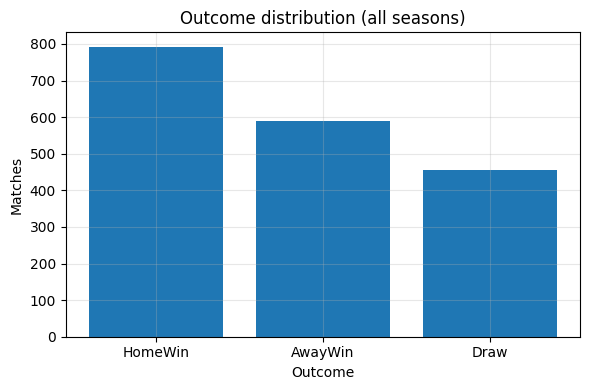

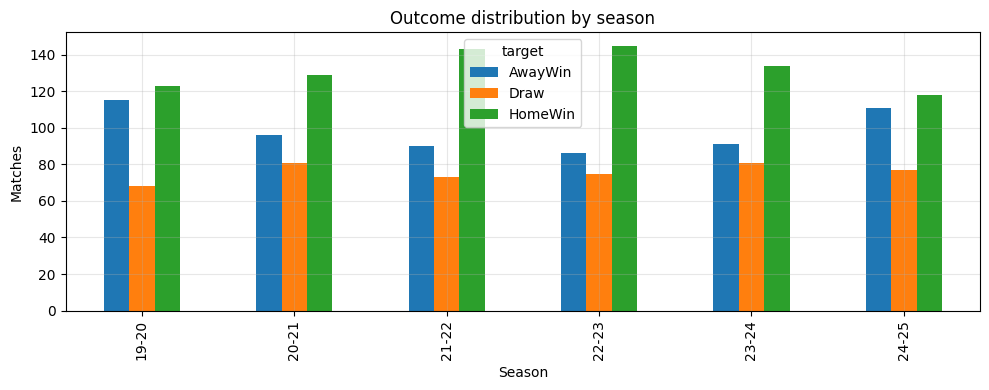

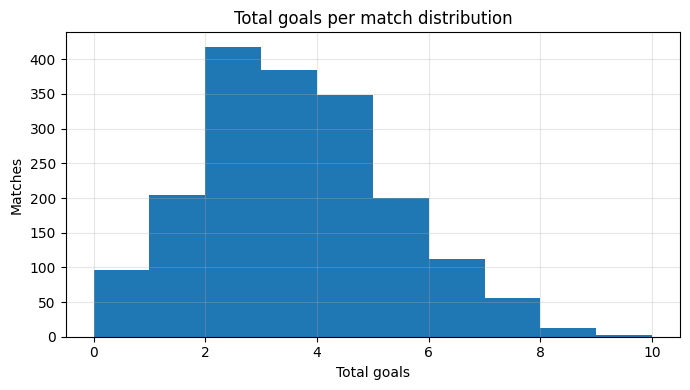

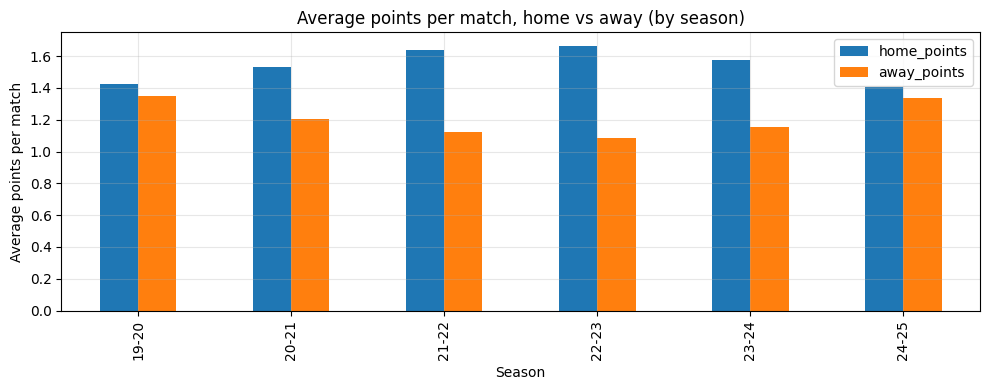

In [37]:
# Target mapping
target_map = {"H": "HomeWin", "D": "Draw", "A": "AwayWin"}
df["target"] = df["FTR"].map(target_map)

# Outcome distribution overall
outcome_counts = df["target"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(outcome_counts.index, outcome_counts.values)
plt.title("Outcome distribution (all seasons)")
plt.xlabel("Outcome")
plt.ylabel("Matches")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Outcome distribution by season (stacked bar)
season_outcomes = (
    df.groupby(["season", "target"]).size().unstack(fill_value=0).sort_index()
)
season_outcomes.plot(kind="bar", figsize=(10, 4))
plt.title("Outcome distribution by season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Goals distribution (total goals)
df["total_goals"] = df["FTHG"] + df["FTAG"]
plt.figure(figsize=(7, 4))
plt.hist(df["total_goals"], bins=range(0, int(df["total_goals"].max()) + 2))
plt.title("Total goals per match distribution")
plt.xlabel("Total goals")
plt.ylabel("Matches")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Home advantage proxy: average points per match for home vs away team by season
def points_from_result(ftr: str):
    if ftr == "H":
        return 3, 0
    if ftr == "A":
        return 0, 3
    return 1, 1

points = df["FTR"].apply(points_from_result)
df["home_points"] = [p[0] for p in points]
df["away_points"] = [p[1] for p in points]

home_adv = df.groupby("season")[["home_points", "away_points"]].mean().sort_index()
home_adv.plot(kind="bar", figsize=(10, 4))
plt.title("Average points per match, home vs away (by season)")
plt.xlabel("Season")
plt.ylabel("Average points per match")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3) Data Preparation

**Leakage prevention rule:** For each fixture, features must use only matches played **before** that fixture.

Feature engineering strategy:
- compute rolling and season-to-date team form,
- derive match-up features as home minus away differences,
- reset team histories at season boundaries.


In [38]:
from collections import defaultdict, deque

def safe_mean(x):
    return float(np.mean(x)) if len(x) > 0 else np.nan

def build_leakage_safe_features(season_df: pd.DataFrame, rolling_n: int = 5) -> pd.DataFrame:
    # Sort chronologically
    season_df = season_df.sort_values("datetime").reset_index(drop=True).copy()

    # Team history containers
    hist_points = defaultdict(list)
    hist_gf = defaultdict(list)
    hist_ga = defaultdict(list)

    rows = []
    for i, r in season_df.iterrows():
        h = r["HomeTeam"]
        a = r["AwayTeam"]

        # Home stats, before current match
        h_points = hist_points[h]
        h_gf = hist_gf[h]
        h_ga = hist_ga[h]
        h_gd = [gf - ga for gf, ga in zip(h_gf, h_ga)]

        # Away stats, before current match
        a_points = hist_points[a]
        a_gf = hist_gf[a]
        a_ga = hist_ga[a]
        a_gd = [gf - ga for gf, ga in zip(a_gf, a_ga)]

        # Rolling windows
        h_points_roll = safe_mean(h_points[-rolling_n:])
        a_points_roll = safe_mean(a_points[-rolling_n:])

        h_gf_roll = safe_mean(h_gf[-rolling_n:])
        a_gf_roll = safe_mean(a_gf[-rolling_n:])

        h_ga_roll = safe_mean(h_ga[-rolling_n:])
        a_ga_roll = safe_mean(a_ga[-rolling_n:])

        h_gd_roll = safe_mean(h_gd[-rolling_n:])
        a_gd_roll = safe_mean(a_gd[-rolling_n:])

        # Season-to-date
        h_ppg_season = safe_mean(h_points)
        a_ppg_season = safe_mean(a_points)

        h_gd_season = safe_mean(h_gd)
        a_gd_season = safe_mean(a_gd)

        # Build feature row (primarily form-gap)
        row = {
            "season": r["season"],
            "datetime": r["datetime"],
            "HomeTeam": h,
            "AwayTeam": a,
            "target": target_map.get(r["FTR"], np.nan),

            # Individual rolling and season features
            "h_roll_ppg": h_points_roll,
            "a_roll_ppg": a_points_roll,
            "h_roll_gd": h_gd_roll,
            "a_roll_gd": a_gd_roll,
            "h_roll_gf": h_gf_roll,
            "a_roll_gf": a_gf_roll,
            "h_roll_ga": h_ga_roll,
            "a_roll_ga": a_ga_roll,
            "h_season_ppg": h_ppg_season,
            "a_season_ppg": a_ppg_season,
            "h_season_gd": h_gd_season,
            "a_season_gd": a_gd_season,

            # Home minus away differences (main modeling features)
            "diff_roll_ppg": h_points_roll - a_points_roll if not (np.isnan(h_points_roll) or np.isnan(a_points_roll)) else np.nan,
            "diff_roll_gd": h_gd_roll - a_gd_roll if not (np.isnan(h_gd_roll) or np.isnan(a_gd_roll)) else np.nan,
            "diff_roll_gf": h_gf_roll - a_gf_roll if not (np.isnan(h_gf_roll) or np.isnan(a_gf_roll)) else np.nan,
            "diff_roll_ga": h_ga_roll - a_ga_roll if not (np.isnan(h_ga_roll) or np.isnan(a_ga_roll)) else np.nan,
            "diff_season_ppg": h_ppg_season - a_ppg_season if not (np.isnan(h_ppg_season) or np.isnan(a_ppg_season)) else np.nan,
            "diff_season_gd": h_gd_season - a_gd_season if not (np.isnan(h_gd_season) or np.isnan(a_gd_season)) else np.nan,
        }
        rows.append(row)

        # Update histories AFTER features
        ftr = r["FTR"]
        fthg = int(r["FTHG"])
        ftag = int(r["FTAG"])

        if ftr == "H":
            hp, ap = 3, 0
        elif ftr == "A":
            hp, ap = 0, 3
        else:
            hp, ap = 1, 1

        hist_points[h].append(hp)
        hist_points[a].append(ap)

        hist_gf[h].append(fthg)
        hist_ga[h].append(ftag)

        hist_gf[a].append(ftag)
        hist_ga[a].append(fthg)

    return pd.DataFrame(rows)

# Apply per season (history resets at season boundary)
feat = pd.concat(
    [build_leakage_safe_features(df[df["season"] == s], rolling_n=5) for s in sorted(df["season"].unique())],
    ignore_index=True,
)

print("Feature table:", feat.shape)
feat.head()


Feature table: (1836, 23)


,season,datetime,HomeTeam,AwayTeam,target,h_roll_ppg,a_roll_ppg,h_roll_gd,a_roll_gd,h_roll_gf,a_roll_gf,h_roll_ga,a_roll_ga,h_season_ppg,a_season_ppg,h_season_gd,a_season_gd,diff_roll_ppg,diff_roll_gd,diff_roll_gf,diff_roll_ga,diff_season_ppg,diff_season_gd
0,19-20,2019-08-16 19:30:00,Bayern Munich,Hertha,Draw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19-20,2019-08-17 14:30:00,Dortmund,Augsburg,HomeWin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19-20,2019-08-17 14:30:00,Freiburg,Mainz,HomeWin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19-20,2019-08-17 14:30:00,Leverkusen,Paderborn,HomeWin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19-20,2019-08-17 14:30:00,Werder Bremen,Fortuna Dusseldorf,AwayWin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
# Check missingness in engineered features
feature_cols = [c for c in feat.columns if c.startswith("diff_")]
missing_feat = feat[feature_cols].isna().mean().sort_values(ascending=False)
display(missing_feat)

# A quick look at feature distributions
feat[feature_cols].describe().T


,0
diff_roll_ppg,0.029412
diff_roll_gd,0.029412
diff_roll_gf,0.029412
diff_roll_ga,0.029412
diff_season_ppg,0.029412
diff_season_gd,0.029412


,count,mean,std,min,25%,50%,75%,max
diff_roll_ppg,1782.0,-0.045464,1.026723,-3.0,-0.800000,0.0,0.600000,3.0
diff_roll_gd,1782.0,-0.085634,1.665811,-7.0,-1.200000,0.0,1.000000,6.0
diff_roll_gf,1782.0,-0.035138,1.099181,-5.0,-0.800000,0.0,0.600000,4.0
diff_roll_ga,1782.0,0.050496,1.000194,-4.5,-0.600000,0.0,0.600000,5.0
diff_season_ppg,1782.0,-0.032025,0.849830,-3.0,-0.535714,0.0,0.500000,3.0
diff_season_gd,1782.0,-0.050602,1.454460,-7.0,-0.937500,0.0,0.851389,6.0


### Train, validation, and test split

To mimic deployment:
- Train: 2019-20 to 2023-24 (chronological),
- Test: 2024-25 (future hold-out, never touched during tuning).


In [40]:
TEST_SEASON = "24-25"

train = feat[feat["season"] != TEST_SEASON].copy()
test = feat[feat["season"] == TEST_SEASON].copy()

# Sort train chronologically for time series CV
train = train.sort_values("datetime").reset_index(drop=True)
test = test.sort_values("datetime").reset_index(drop=True)

X_train = train[feature_cols]
y_train = train["target"]

X_test = test[feature_cols]
y_test = test["target"]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train target distribution:")
display(y_train.value_counts(normalize=True))


Train: (1530, 6) Test: (306, 6)
Train target distribution:


,proportion
target,
HomeWin,0.440523
AwayWin,0.312418
Draw,0.247059


## 4) Modeling

Models compared:
- naive baselines (sanity checks),
- multinomial Logistic Regression (interpretable baseline),
- XGBoost classifier (advanced model).

Tuning:
- `GridSearchCV` with `TimeSeriesSplit`,
- selection metric: Macro F1 (class-balanced).


In [41]:
# Helper: multiclass Brier score
def multiclass_brier_score(y_true, proba, classes):
    # One-hot encode
    y_map = {c: i for i, c in enumerate(classes)}
    y_idx = np.array([y_map[v] for v in y_true])
    y_oh = np.zeros_like(proba)
    y_oh[np.arange(len(y_idx)), y_idx] = 1.0
    return np.mean(np.sum((proba - y_oh) ** 2, axis=1))

# Consistent class order
CLASSES = ["HomeWin", "Draw", "AwayWin"]

# Naive baselines probabilities
def baseline_proba(strategy: str, y_train: pd.Series, n: int):
    if strategy == "always_home":
        # P(HomeWin)=1
        proba = np.zeros((n, 3))
        proba[:, 0] = 1.0
        return proba
    if strategy == "majority":
        maj = y_train.value_counts().idxmax()
        proba = np.zeros((n, 3))
        proba[:, CLASSES.index(maj)] = 1.0
        return proba
    raise ValueError("Unknown strategy")

baseline_results = []
for strat in ["always_home", "majority"]:
    p = baseline_proba(strat, y_train, len(y_test))
    y_pred = [CLASSES[i] for i in np.argmax(p, axis=1)]
    baseline_results.append({
        "model": strat,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "log_loss": log_loss(y_test, p, labels=CLASSES),
        "brier": multiclass_brier_score(y_test, p, CLASSES),
    })

pd.DataFrame(baseline_results)


,model,accuracy,macro_f1,log_loss,brier
0,always_home,0.385621,0.185535,22.968995,1.228758
1,majority,0.385621,0.185535,22.968995,1.228758


In [42]:
# Logistic Regression pipeline
tscv = TimeSeriesSplit(n_splits=5)

logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=500,
        random_state=RANDOM_STATE,
    )),
])

param_grid_logreg = {
    "clf__C": [0.1, 1.0] if QUICK_RUN else [0.1, 1.0, 10.0],
    "clf__class_weight": [None, "balanced"],
}

grid_logreg = GridSearchCV(
    logreg,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

grid_logreg.fit(X_train, y_train)
print("Best Logistic Regression params:", grid_logreg.best_params_)
print("Best CV Macro F1:", grid_logreg.best_score_)


Best Logistic Regression params: {'clf__C': 1.0, 'clf__class_weight': 'balanced'}
Best CV Macro F1: 0.42370647380212023


In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Class mapping: {'AwayWin': np.int64(0), 'Draw': np.int64(1), 'HomeWin': np.int64(2)}


In [44]:
# XGBoost pipeline (advanced model)
xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
    )),
])

param_grid_xgb = {
    "clf__max_depth": [2, 3] if QUICK_RUN else [2, 3, 4],
    "clf__learning_rate": [0.1] if QUICK_RUN else [0.05, 0.1],
    "clf__n_estimators": [300] if QUICK_RUN else [250, 500],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid=param_grid_xgb,
    scoring="f1_macro",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)

grid_xgb.fit(X_train, y_train_enc)

best_xgb = grid_xgb.best_estimator_
print("XGB classes_:", best_xgb.named_steps["clf"].classes_)
print("LabelEncoder classes_:", le.classes_)


XGB classes_: [0 1 2]
LabelEncoder classes_: ['AwayWin' 'Draw' 'HomeWin']


## 5) Evaluation

Final evaluation is on the 2024-25 hold-out season.

We report:
- class metrics: accuracy, Macro F1, confusion matrix,
- probability metrics: log loss, multiclass Brier score,
- calibration curves (one-vs-rest),
- optional diagnostics (per-team mean NLL).


In [47]:
def evaluate_model(
    name: str,
    model,
    X_test,
    y_test,
    classes_order,
    label_encoder=None,   # pass le for xgboost, None for logreg
):
    proba = model.predict_proba(X_test)

    # Get classifier classes_ if available
    clf = model.named_steps["clf"] if hasattr(model, "named_steps") else model
    if hasattr(clf, "classes_"):
        model_classes = list(clf.classes_)
    else:
        model_classes = list(range(proba.shape[1]))

    # If XGBoost was trained on encoded labels, map 0/1/2 back to strings
    if label_encoder is not None and all(isinstance(c, (int, np.integer)) for c in model_classes):
        model_labels = list(label_encoder.inverse_transform(np.array(model_classes, dtype=int)))
    else:
        model_labels = list(model_classes)

    # Reorder proba columns to match classes_order (your CLASSES)
    if model_labels != classes_order:
        idx = [model_labels.index(c) for c in classes_order]
        proba = proba[:, idx]

    y_pred = [classes_order[i] for i in np.argmax(proba, axis=1)]

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "log_loss": log_loss(y_test, proba, labels=classes_order),
        "brier": multiclass_brier_score(y_test, proba, classes_order),
        "y_pred": np.array(y_pred),
        "proba": proba,
    }


In [48]:
best_logreg = grid_logreg.best_estimator_
best_xgb    = grid_xgb.best_estimator_

results = []
artifacts = {}

# Baselines
for b in baseline_results:
    results.append({k: v for k, v in b.items()})

# Models
for name, mdl in [("logreg", best_logreg), ("xgboost", best_xgb)]:
    out = evaluate_model(
        name=name,
        model=mdl,
        X_test=X_test,
        y_test=y_test,
        classes_order=CLASSES,
        label_encoder=(le if name == "xgboost" else None),
    )
    results.append({k: out[k] for k in ["model", "accuracy", "macro_f1", "log_loss", "brier"]})
    artifacts[name] = out

pd.DataFrame(results).sort_values("macro_f1", ascending=False)


,model,accuracy,macro_f1,log_loss,brier
3,xgboost,0.450980,0.380286,1.372663,0.672071
2,logreg,0.395425,0.376237,1.251210,0.641540
1,majority,0.385621,0.185535,22.968995,1.228758
0,always_home,0.385621,0.185535,22.968995,1.228758


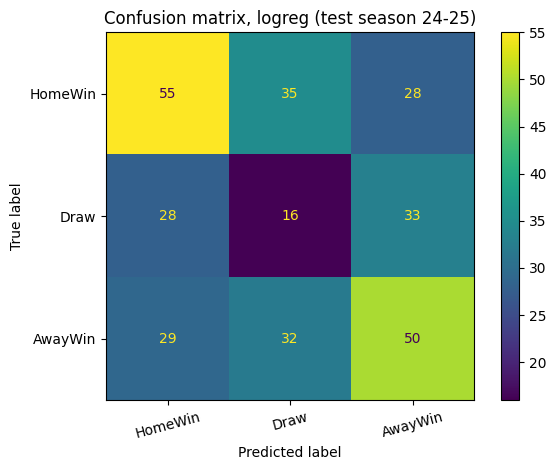

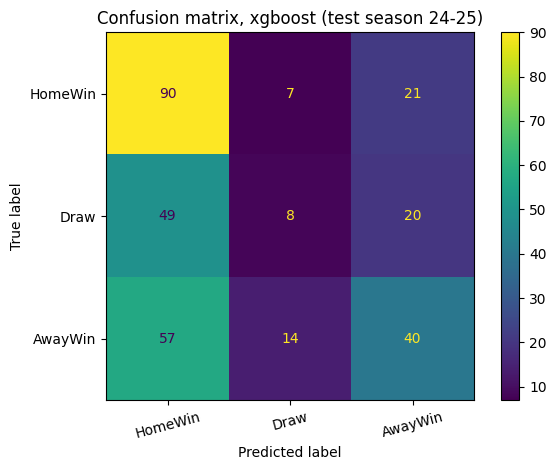

In [49]:
# Confusion matrices for tuned models
for name in ["logreg", "xgboost"]:
    y_pred = artifacts[name]["y_pred"]
    cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot()
    plt.title(f"Confusion matrix, {name} (test season {TEST_SEASON})")
    plt.xticks(rotation=15)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


In [50]:
from sklearn.metrics import classification_report

FINAL_MODEL = "logreg"

y_pred_final = artifacts[FINAL_MODEL]["y_pred"]

print(f"Classification report (test season {TEST_SEASON}), final model: {FINAL_MODEL}")
print(classification_report(y_test, y_pred_final, labels=CLASSES, digits=3))


Classification report (test season 24-25), final model: logreg
              precision    recall  f1-score   support

     HomeWin      0.491     0.466     0.478       118
        Draw      0.193     0.208     0.200        77
     AwayWin      0.450     0.450     0.450       111

    accuracy                          0.395       306
   macro avg      0.378     0.375     0.376       306
weighted avg      0.401     0.395     0.398       306



In [51]:
rep = classification_report(
    y_test,
    y_pred_final,
    labels=CLASSES,
    output_dict=True
)

print(f"Draw recall: {rep['Draw']['recall']:.3f}")
print(f"Draw F1: {rep['Draw']['f1-score']:.3f}")


Draw recall: 0.208
Draw F1: 0.200


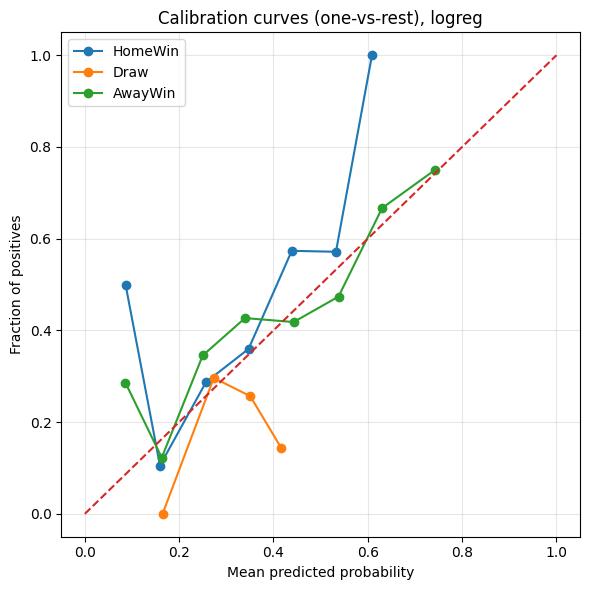

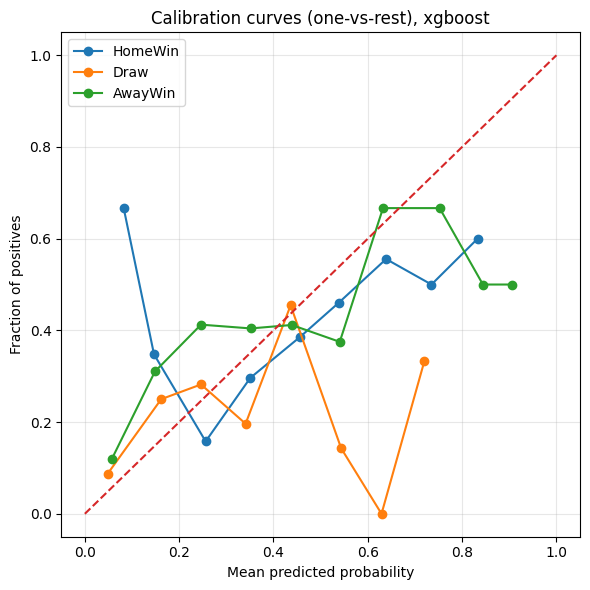

In [52]:
# Calibration curves, one-vs-rest per class
def plot_calibration(y_true, proba, model_name, n_bins=10):
    plt.figure(figsize=(6, 6))
    for i, cls in enumerate(CLASSES):
        y_bin = (np.array(y_true) == cls).astype(int)
        frac_pos, mean_pred = calibration_curve(y_bin, proba[:, i], n_bins=n_bins, strategy="uniform")
        plt.plot(mean_pred, frac_pos, marker="o", label=cls)

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"Calibration curves (one-vs-rest), {model_name}")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for name in ["logreg", "xgboost"]:
    plot_calibration(y_test, artifacts[name]["proba"], name)


,matches,mean_nll
Team,,
Dortmund,34,1.140571
Wolfsburg,34,1.130595
Union Berlin,34,1.128741
RB Leipzig,34,1.123437
St Pauli,34,1.090792
M'gladbach,34,1.086932
Stuttgart,34,1.084852
Werder Bremen,34,1.084339
Augsburg,34,1.082978


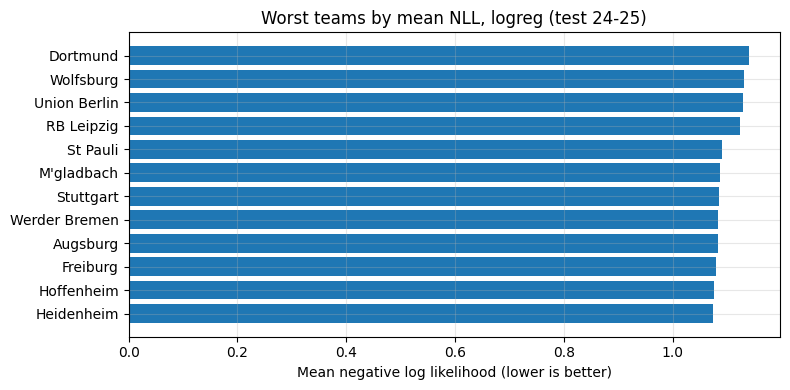

,matches,mean_nll
Team,,
Augsburg,34,1.276869
Union Berlin,34,1.275730
Stuttgart,34,1.258551
Werder Bremen,34,1.253655
RB Leipzig,34,1.251157
Freiburg,34,1.198600
Leverkusen,34,1.190511
Mainz,34,1.157366
Heidenheim,34,1.157032


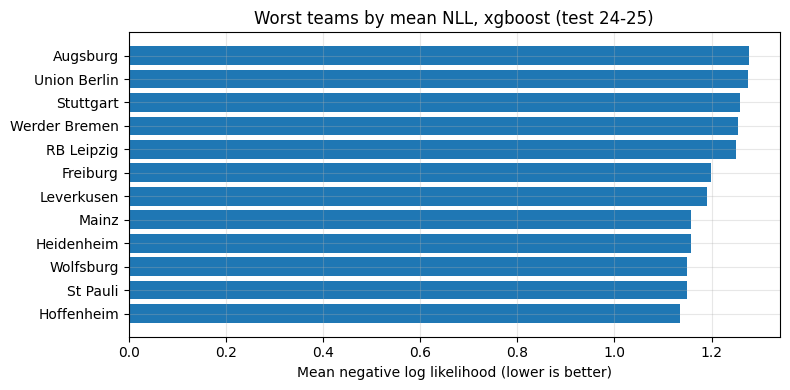

In [53]:
# Per-team negative log likelihood (NLL) analysis
# Assign each match's NLL to both teams involved.
def per_team_nll(test_df_meta: pd.DataFrame, y_true, proba):
    # NLL per match
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    idx = np.array([class_to_idx[v] for v in y_true])
    eps = 1e-12
    nll = -np.log(np.clip(proba[np.arange(len(idx)), idx], eps, 1.0))

    tmp = test_df_meta[["HomeTeam", "AwayTeam"]].copy()
    tmp["nll"] = nll

    long = pd.concat([
        tmp.rename(columns={"HomeTeam": "Team"})[["Team", "nll"]],
        tmp.rename(columns={"AwayTeam": "Team"})[["Team", "nll"]],
    ], ignore_index=True)

    out = long.groupby("Team").agg(matches=("nll", "size"), mean_nll=("nll", "mean")).sort_values("mean_nll", ascending=False)
    return out

test_meta = test[["HomeTeam", "AwayTeam", "datetime"]].copy()

for name in ["logreg", "xgboost"]:
    team_scores = per_team_nll(test_meta, y_test, artifacts[name]["proba"])
    display(team_scores.head(10))

    # Plot worst 12 teams by mean NLL
    worst = team_scores.head(12).sort_values("mean_nll", ascending=True)
    plt.figure(figsize=(8, 4))
    plt.barh(worst.index, worst["mean_nll"])
    plt.title(f"Worst teams by mean NLL, {name} (test {TEST_SEASON})")
    plt.xlabel("Mean negative log likelihood (lower is better)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


,diff_roll_ppg,diff_roll_gd,diff_roll_gf,diff_roll_ga,diff_season_ppg,diff_season_gd
AwayWin,0.008866,0.005494,-0.068730,-0.086882,-0.154049,-0.353674
Draw,0.041829,-0.047582,0.008483,0.090974,0.143018,0.021612
HomeWin,-0.050695,0.042087,0.060247,-0.004092,0.011031,0.332063


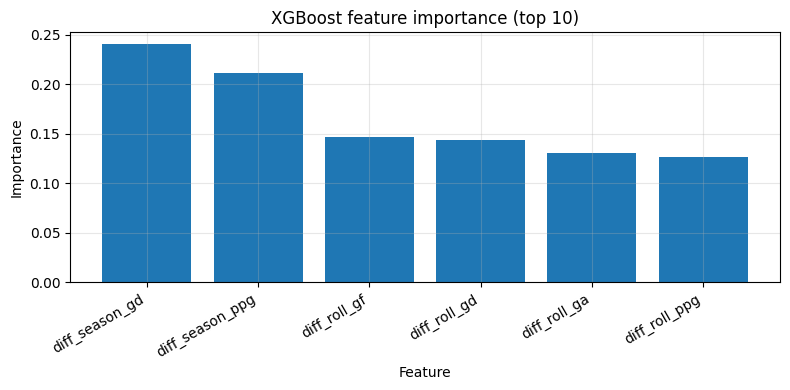

In [54]:
# Feature importance / coefficients for interpretability

# Logistic Regression coefficients (per class)
logreg_clf = best_logreg.named_steps["clf"]
coef = pd.DataFrame(logreg_clf.coef_, columns=feature_cols, index=logreg_clf.classes_)
display(coef)

# XGBoost feature importance
xgb_clf = best_xgb.named_steps["clf"]
imp = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(imp.index[:10], imp.values[:10])
plt.title("XGBoost feature importance (top 10)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Discussion and next iteration

Key takeaway: form features contain signal but are insufficient for strong draw separation.

Next iteration priorities (still pre-match):
- stronger team-strength priors (Elo / table position),
- schedule and fatigue features (rest days, congestion),
- richer context features (if available), and decision-aligned targets (e.g., avoid defeat).
